In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt

import h5py
import sys
sys.path.append('../')
import analysis_utils as utils

from scipy.signal import welch
from scipy.signal.windows import hann
from scipy.fft import fft, fftfreq, rfft, irfft, rfftfreq
from scipy.special import voigt_profile
from scipy.optimize import curve_fit

yale_colors = ['#00356b', '#286dc0', '#63aaff', '#4a4a4a']
utils.load_plotting_setting()

In [35]:
rho = 2000 # kg/m^3
m = rho * (83e-9)**3 * 4 * np.pi / 3

def get_sz_measured(dt, zz, n_spectrum, n_chunk, c_mv):
    fs = int(np.ceil(1 / dt))

    size_per_chunk = int(zz.size / n_chunk)
    hann_window = hann(size_per_chunk)

    # Correction factor for Hann windowing
    # See https://dsp.stackexchange.com/questions/93512/effects-of-hanning-window-on-power
    hann_psd_scaling = np.sum(hann_window**2)

    ff, s_zzs, s_ffs = None, [], []
    for i in range(n_spectrum):
        zz_calc = zz[i*size_per_chunk : (i+1)*size_per_chunk]
        zz_windowed = hann_window * zz_calc

        s_zz = np.abs(rfft(zz_windowed))**2 / (fs * hann_psd_scaling)
        s_zzs.append(s_zz)

        ff = rfftfreq(size_per_chunk, dt)

    s_zs = 2 * np.array(s_zzs)
    sz_measured = np.mean(s_zs, axis=0) * c_mv**2
    
    return ff, sz_measured

def voigt(xx, A, x0, sigma, gamma):
    return A * voigt_profile(xx-x0, sigma, gamma)

def fit_sigma_voigt(ff, sz, gamma=None):
    fit_idx_voigt = np.logical_and(ff > 49500, ff < 52000)

    popt, pcov = curve_fit(lambda xx, A, f0, sigma, gamma: voigt(xx, A, f0, sigma, gamma), ff[fit_idx_voigt]*2*np.pi, sz[fit_idx_voigt], 
                           p0=[3e-18, 50500*2*np.pi, 50*2*np.pi, 1*2*np.pi], sigma=sz[fit_idx_voigt])
    
    return popt

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

def gaussian_convolved_lineshape(omega, A, omega0, sigma, gamma):
    xx_gauss = np.arange(-400*2*np.pi, 400*2*np.pi, 1)
    gauss_kernel = gauss(xx_gauss, A=1, mu=0, sigma=sigma)
    gauss_kernel /= np.sum(gauss_kernel)

    xx = np.arange(20000*2*np.pi, 120000*2*np.pi, 1)
    actual_lineshape = A / ((xx**2 - omega0**2)**2 + gamma**2 * xx**2)
    
    convolved_lineshape = np.convolve(gauss_kernel, actual_lineshape, 'same')
    return np.interp(omega, xx, convolved_lineshape)

In [45]:
_files = [
    r'/Users/yuhan/work/nanospheres/data/lorentz_force/20250731_2e-8mbar_electric_calibration/20250731_11e_2_5vpp_93khz_z_electrode1_0.hdf5',
    r'/Users/yuhan/work/nanospheres/data/lorentz_force/20250731_2e-8mbar_electric_calibration/20250731_11e_2_5vpp_93khz_z_electrode1_1.hdf5',
    r'/Users/yuhan/work/nanospheres/data/lorentz_force/20250731_2e-8mbar_electric_calibration/20250731_11e_2_5vpp_93khz_z_electrode1_2.hdf5',
    r'/Users/yuhan/work/nanospheres/data/lorentz_force/20250731_2e-8mbar_electric_calibration/20250731_11e_2_5vpp_93khz_z_electrode1_3.hdf5',
    r'/Users/yuhan/work/nanospheres/data/lorentz_force/20250731_2e-8mbar_electric_calibration/20250731_11e_2_5vpp_93khz_z_electrode1_4.hdf5',
]

c_mvs = utils.get_c_mv(_files, [2.5], 93000*2*np.pi, passband=(91700, 94300), charge=11, n_chunk=60, efield=138)
c_mv  = np.mean(c_mvs)

print(f'c_mv: {c_mv}')

c_mv: 2.5586835233228296e-07


In [ ]:
# _file = r'/Users/yuhan/work/nanospheres/data/lorentz_force/20250813_m350e_276khz_350vpp_withb_0.hdf5'
_file = r'/Users/yuhan/work/nanospheres/data/lorentz_force/20250808_2e-8mbar_electric_calibration/20250808_m350e_93khz_2_5vpp_nob_0.hdf5'
f = h5py.File(_file, 'r')
dt = f['data'].attrs['delta_t']
zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V


# ff, pp = utils.get_psd(dt=dt, zz=dd)
ff, sz_measured = get_sz_measured(dt, zz, n_spectrum=10, n_chunk=400, c_mv=c_mv)

A, omega0, sigma, gamma_voigt = fit_sigma_voigt(ff, sz_measured)

gamma = gamma_voigt * 2
convolved_lineshape = gaussian_convolved_lineshape(ff*2*np.pi, 1, omega0, sigma, gamma)
chi_2_convolved = (1 / (m**2)) * convolved_lineshape

sf_measured_convolved = sz_measured / (chi_2_convolved)

In [53]:
np.min(sf_measured_convolved)

4.079240633145922e-40

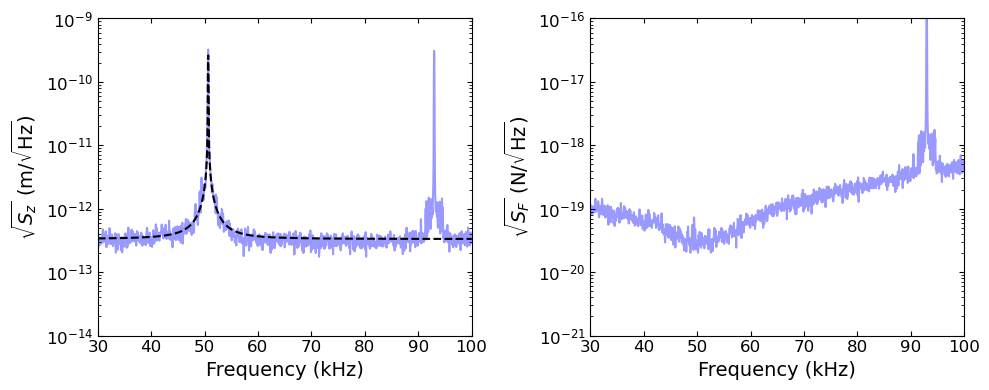

In [ ]:
fit_idx = np.logical_and(ff > 200000, ff < 250000)
sz_noisefloor = np.mean(sz_measured[fit_idx])
omega = ff * 2 * np.pi

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(ff/1000, np.sqrt(sz_measured), color='b', alpha=0.4)
axes[0].plot(ff/1000, np.sqrt(voigt(omega, A, omega0, sigma, gamma_voigt) + sz_noisefloor), 'k--', label='Voigt fit')
axes[1].plot(ff/1000, np.sqrt(sf_measured_convolved), color='b', alpha=0.4)

for ax in axes:
    ax.set_xlim(30, 100)
axes[0].set_ylim(1e-14, 1e-9)
axes[1].set_ylim(1e-21, 1e-16)

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Frequency (kHz)')

axes[0].set_ylabel(r'$\sqrt{S_z}$ (m/$\sqrt{\mathrm{Hz}}$)')
axes[1].set_ylabel(r'$\sqrt{S_F}$ (N/$\sqrt{\mathrm{Hz}}$)')

fig.tight_layout()